<a href="https://colab.research.google.com/github/MaysNassar/PCA-for-Data-Visualization-Exercise-Practice-/blob/main/PCA_Exercise_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------
# **PCA Exercise (Core)**


- Mays Nassar

> Comparsion Between Default KNN Classifire's Speed and Performance for A **Non-PCA** Dataset and a **PCA** Dataset

------------------------------------

# Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.compose import ColumnTransformer
import datetime as dt


pd.set_option('display.max_columns',200)
pd.set_option("display.max_info_rows", 800)
pd.set_option('display.max_info_columns',800)
import datetime as dt

from sklearn import set_config
set_config(transform_output='pandas')

# Define Custom Functions

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  # print header and report
  header = '-'*60
  print(header,f'Classification Metrics: {label}', header, sep='\n')
  print(report)

  ## Confusion Metrics Subplots
  fig, axes =plt.subplots(ncols=2, figsize=figsize)

  # Create confusion matrix of raw matrix
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None,
                                         cmap='gist_gray', colorbar=colorbar,
                                         ax=axes[0]);
  axes[0].set_title('Raw Counts')

  # Create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize,
                                          cmap=cmap, colorbar=colorbar,
                                          ax=axes[1]);
  axes[1].set_title('Normalized Confusion Matrix')

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred,
                                        output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

  # Get prediction for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metric s for training data
  results_train = classification_metrics(y_train, y_train_pred, # verbose = verbose,
                                         output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                         label= 'Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose=verbose,
                                        output_dict=True, figsize=figsize,
                                        colorbar=colorbar, cmap=cmap_test,
                                        label = 'Test Data')
  if output_dict == True:
    # Store results in a dataframe if output_frame is True
    results_dict = {'train': results_train,
                    'test': results_test}
    return results_dict

# Load the data

In [4]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [63]:
# Load the data
df= pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week17/Data/NHANES_Diet_Diabetes_Risk.xls.csv')
df =df.set_index('SEQN')
df.head()

,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,DBD100,DRQSPREP,DR1STY,DR1SKY,DRQSDIET,DRQSDT1,DRQSDT2,DRQSDT3,DRQSDT4,DRQSDT5,DRQSDT6,DRQSDT7,DRQSDT8,DRQSDT9,DRQSDT10,DRQSDT11,DRQSDT12,DRQSDT91,DR1TNUMF,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,DR1TVB6,DR1TFOLA,DR1TFA,DR1TFF,DR1TFDFE,DR1TCHL,DR1TVB12,DR1TB12A,DR1TVC,DR1TVD,DR1TVK,DR1TCALC,DR1TPHOS,DR1TMAGN,DR1TIRON,DR1TZINC,DR1TCOPP,DR1TSODI,DR1TPOTA,DR1TSELE,DR1TCAFF,DR1TTHEO,DR1TALCO,DR1TMOIS,DR1TS040,DR1TS060,DR1TS080,DR1TS100,DR1TS120,DR1TS140,DR1TS160,DR1TS180,DR1TM161,DR1TM181,DR1TM201,DR1TM221,DR1TP182,DR1TP183,DR1TP184,DR1TP204,DR1TP205,DR1TP225,DR1TP226,DR1.300,DR1.320Z,DR1.330Z,DR1BWATZ,DR1TWS,DRD340,DRD350A,DRD350AQ,DRD350B,DRD350BQ,DRD350C,DRD350CQ,DRD350D,DRD350DQ,DRD350E,DRD350EQ,DRD350F,DRD350FQ,DRD350G,DRD350GQ,DRD350H,DRD350HQ,DRD350I,DRD350IQ,DRD350J,DRD350JQ,DRD350K,DRD360,DRD370A,DRD370AQ,DRD370B,DRD370BQ,DRD370C,DRD370CQ,DRD370D,DRD370DQ,DRD370E,DRD370EQ,DRD370F,DRD370FQ,DRD370G,DRD370GQ,DRD370H,DRD370HQ,DRD370I,DRD370IQ,DRD370J,DRD370JQ,DRD370K,DRD370KQ,DRD370L,DRD370LQ,DRD370M,DRD370MQ,DRD370N,DRD370NQ,DRD370O,DRD370OQ,DRD370P,DRD370PQ,DRD370Q,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V,Diabetes_Risk
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
73557,16888.32786,12930.89065,1,49.0,2.0,2.0,6.0,2.0,1.0,1.0,13.0,3.0,2.0,4.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,1574.0,43.63,239.59,176.47,10.8,52.81,17.819,18.493,8.829,209.0,3.92,0.0,70.0,110.0,60.0,304.0,278.0,1398.0,430.0,1.057,1.216,11.804,0.951,285.0,66.0,219.0,330.0,216.3,2.79,0.00,241.4,3.3,29.2,949.0,756.0,206.0,8.41,8.85,1.072,1323.0,2228.0,62.5,203.0,36.0,0.0,2701.79,0.219,0.099,0.103,0.153,0.346,1.221,9.694,5.408,1.173,16.796,0.121,0.001,7.932,0.769,0.000,0.094,0.001,0.000,0.010,2.0,960.0,960.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
73558,17932.14387,12684.14887,1,59.0,2.0,2.0,4.0,1.0,1.0,1.0,13.0,1.0,2.0,3.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,5062.0,338.13,423.78,44.99,16.7,124.29,53.408,35.481,20.505,2584.0,20.94,0.0,1477.0,1488.0,0.0,145.0,12.0,0.0,899.0,4.178,5.168,65.396,4.415,1243.0,601.0,641.0,1662.0,2149.0,21.45,0.00,2.3,15.2,23.4,3193.0,6427.0,903.0,26.88,30.36,4.130,9726.0,4930.0,715.8,240.0,0.0,119.0,6779.99,1.872,1.160,0.802,1.286,1.297,6.516,27.952,12.107,2.208,32.429,0.086,0.000,15.483,1.774,0.007,0.728,1.003,0.104,1.139,2.0,360.0,360.0,0.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2
73559,59641.81293,39394.23671,1,49.0,2.0,2.0,18.0,6.0,1.0,1.0,13.0,1.0,1.0,2.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,27.0,1743.0,64.61,224.39,102.90,9.9,65.97,25.263,20.902,12.953,88.0,8.87,0.0,616.0,655.0,21.0,449.0,35.0,515.0,300.0,1.648,1.747,18.342,1.906,423.0,290.0,133.0,625.0,161.2,3.78,1.42,195.1,4.0,40.4,877.0,1198.0,210.0,17.57,8.98,0.949,2943.0,1694.0,98.3,45.0,71.0,0.0,3766.70,0.358,0.128,0.371,0.455,3.008,2.067,10.691,7.497,0.531,19.910,0.164,0.005,11.705,1.092,0.000,0.042,0.001,0.006,0.002,2.0,1254.0,0.0,1254.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

# Preprocess the Data

## Define X and y

In [6]:
# Define X and y
target = 'Diabetes_Risk'
X = df.drop(columns=target)
y = df[target]

## Train Test Split

In [7]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


## Check for null Values

<Axes: >

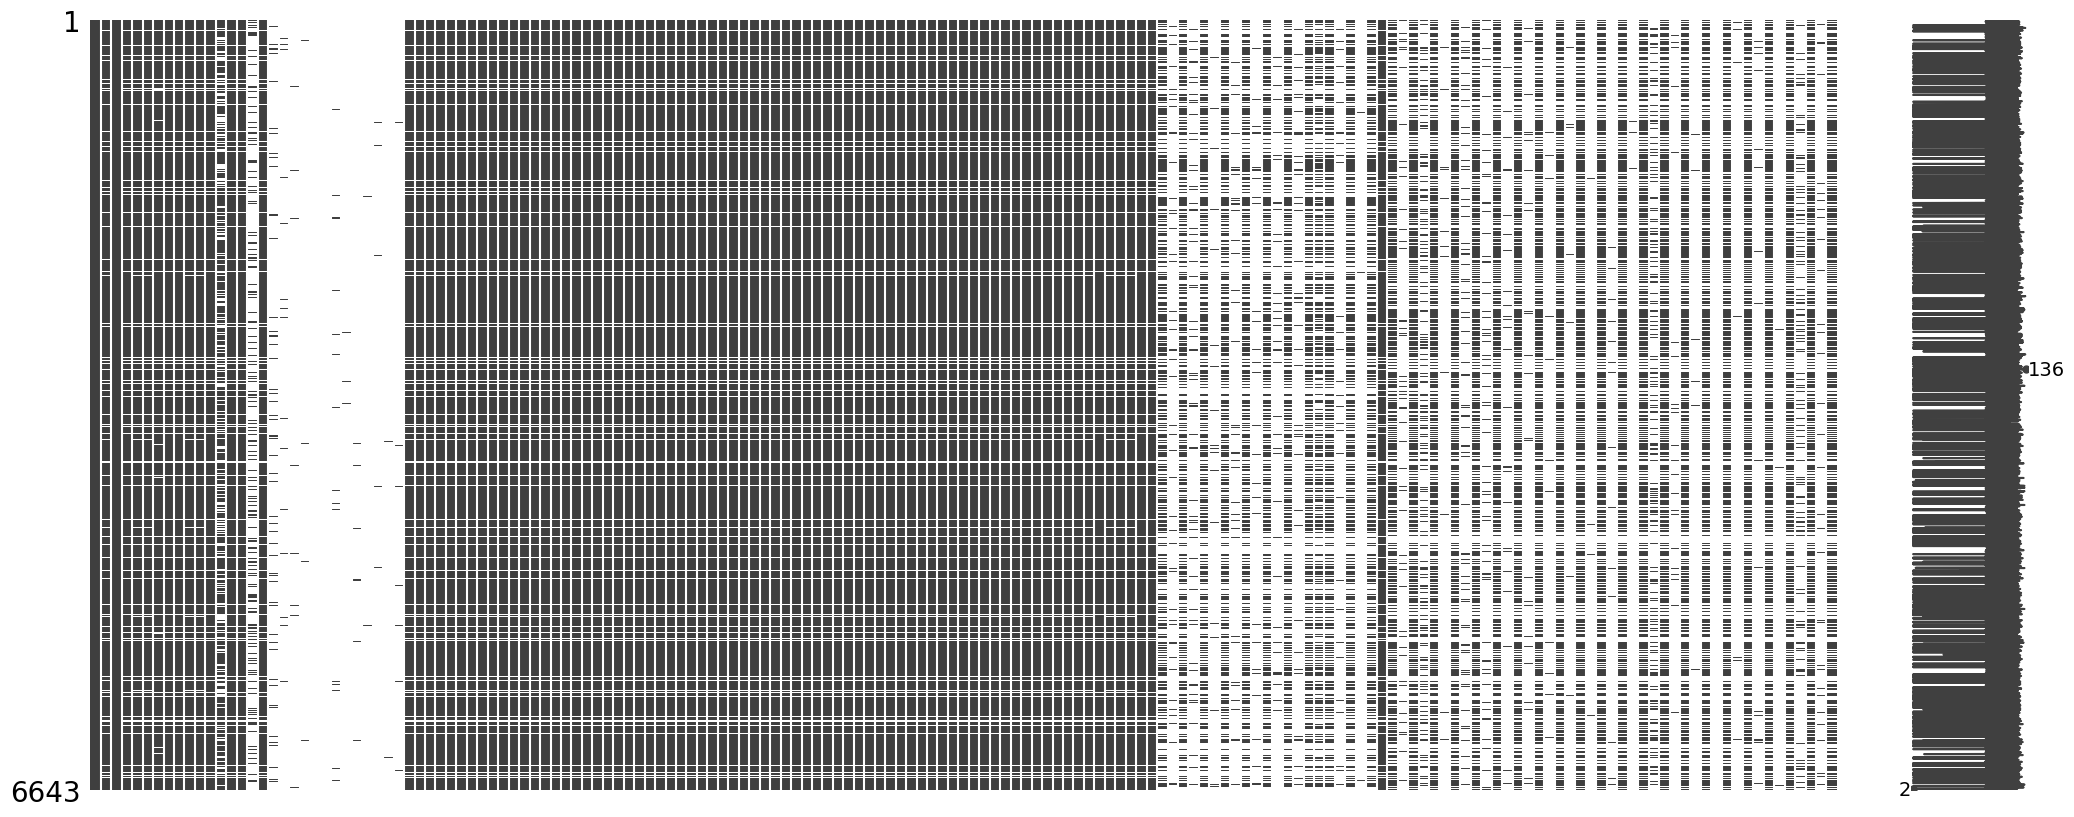

In [8]:
import missingno as msno
msno.matrix(X)

In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

# Verify
print("NaNs after imputation:", pd.DataFrame(X_train_clean).isnull().sum().sum())

NaNs after imputation: 0


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['DRQSDT5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['DRQSDT5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [20]:
print("NaNs in X_train_clean before scaling:", X_train_clean.isna().sum().sum())
print("NaNs in X_test_clean before scaling:", X_test_clean.isna().sum().sum())

NaNs in X_train_clean before scaling: 0
NaNs in X_test_clean before scaling: 0


## Scale the Data

In [21]:
# Instantiate Standard scaler
scaler  = StandardScaler()
# Fit & transform the data
X_train_tf = scaler.fit_transform(X_train_clean)
X_test_tf = scaler.transform(X_test_clean)

## Check for Class Balance

In [22]:
# Check for class balance of target
y_train.value_counts(1)

,proportion
Diabetes_Risk,
0,0.819952
2,0.092332
1,0.087716


# Model- No PCA

In [35]:
# instantiate default Knn
knn = KNeighborsClassifier()

# Fit default KNN model
knn.fit(X_train_tf, y_train)

KNeighborsClassifier()

## Evaluate the model and Record time

In [36]:
# Record the time it takes to make predictions
%%time
preds = knn.predict(X_test_tf)

CPU times: user 220 ms, sys: 2.42 ms, total: 222 ms
Wall time: 299 ms


------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      1.00      0.90      4085
           1       0.49      0.04      0.08       437
           2       0.68      0.04      0.08       460

    accuracy                           0.82      4982
   macro avg       0.66      0.36      0.35      4982
weighted avg       0.78      0.82      0.75      4982



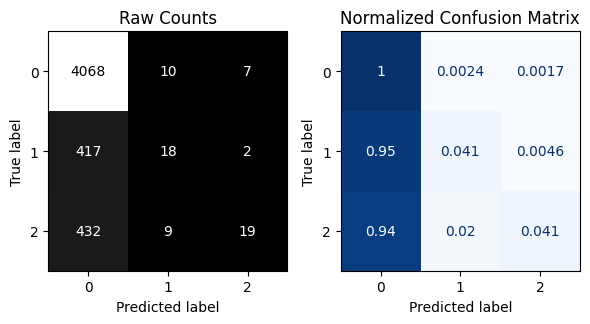


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1367
           1       0.25      0.03      0.05       150
           2       0.27      0.02      0.04       144

    accuracy                           0.82      1661
   macro avg       0.45      0.35      0.33      1661
weighted avg       0.73      0.82      0.75      1661



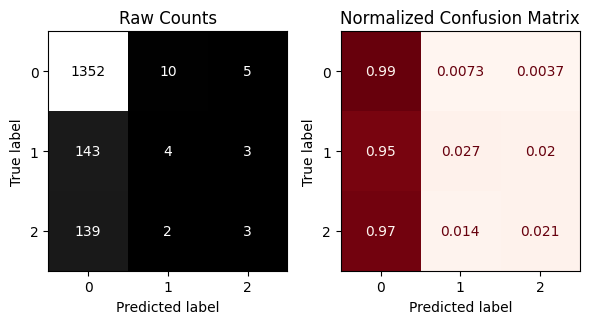

Training time was: 0:00:00.238076


In [41]:
# Import datetime library
import datetime as dt

# Record the start time
start = dt.datetime.now()
preds = knn.predict(X_test_tf)
# Record the end time and calc duration
end = dt.datetime.now()
dur_baseline= end-start

evaluate_classification(knn, X_train_tf, y_train, X_test_tf,y_test)
print(f'Prediction time was: {dur_baseline}')

# Transform the Data with PCA

In [42]:
# Instantiate & Fit data using PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_tf)
X_test_pca = pca.transform(X_test_tf)


In [43]:
# check how many pca components
pca.n_components_

np.int64(99)

In [57]:
print(f"PCA components: {pca.n_components_}")



PCA components: 99


In [44]:
print(f"Original features: {X_train_tf.shape[1]}")
print(f"PCA components: {pca.n_components_}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

Original features: 166
PCA components: 99
Variance explained: 0.9521


# Model- with PCA

In [45]:
# Fit KNN on PCA
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)

KNeighborsClassifier()

## Evaluate model and record time

In [47]:
# Record the time it takes to make predictions
%%time
preds_pca = knn_pca.predict(X_test_pca)

CPU times: user 174 ms, sys: 74 µs, total: 174 ms
Wall time: 368 ms


------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      1.00      0.90      4085
           1       0.50      0.05      0.09       437
           2       0.68      0.04      0.08       460

    accuracy                           0.82      4982
   macro avg       0.67      0.36      0.36      4982
weighted avg       0.79      0.82      0.76      4982



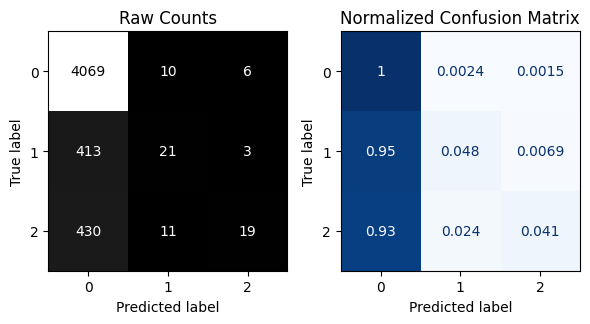


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1367
           1       0.19      0.02      0.04       150
           2       0.20      0.01      0.03       144

    accuracy                           0.82      1661
   macro avg       0.40      0.34      0.32      1661
weighted avg       0.71      0.82      0.75      1661



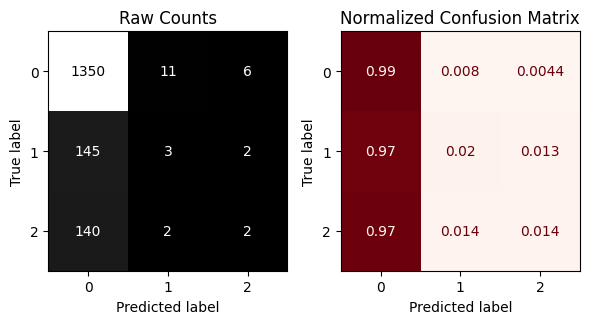

PCA prediction time: 0:00:00.317930


In [52]:

start = dt.datetime.now()
preds_pca = knn_pca.predict(X_test_pca)
end = dt.datetime.now()
dur_pca = end - start
evaluate_classification(knn_pca, X_train_pca, y_train, X_test_pca, y_test)
print(f"PCA prediction time: {dur_pca}")

Q1. How many features were used in the first model, and how many PCs were used in the PCA model?

-  The baseline model used 166 features from the original dataset. The PCA model reduced this to 99 principal components while maintaining 95% of the variance.


Q2. Which model performed the best on the test set?
 - **KNN Model** (No PCA):         
    - Accuracy 0.82
    -  Precision 0.73
    -  Recall 0.82
    -  F1 0.75
    - prediction time: 238 ms
- **PCA Model**:
   -  Accuracy 0.82
   -  Precision 0.71
   -  Recall 0.82
   -  F1 0.75
   - PCA prediction time: 174 ms


 >Both models achieved the same accuracy (0.82) on the test set. However, the baseline model had slightly better weighted average precision (0.73 vs 0.71) and equal recall (0.82). The models performed essentially identically in terms of predictive accuracy, with negligible differences in other metrics.


Q3. Which model was the fastest at making predictions?
 - Compare prediction times: PCA is faster: 174 ms vs. 238 ms baseline.
The PCA model was faster, taking 174 ms to make predictions.
